<a href="https://colab.research.google.com/github/ps-research/FinDex/blob/main/PPMI_Analysis_Updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loaded 2408 samples from the dataset

Found 7 intent labels and 6 impact labels
PPMI Matrix calculated!

Generating Publication-Ready Visualizations

Saved high-quality PDF to: ppmi_heatmap_full.pdf
Saved PNG preview to: ppmi_heatmap_full.png


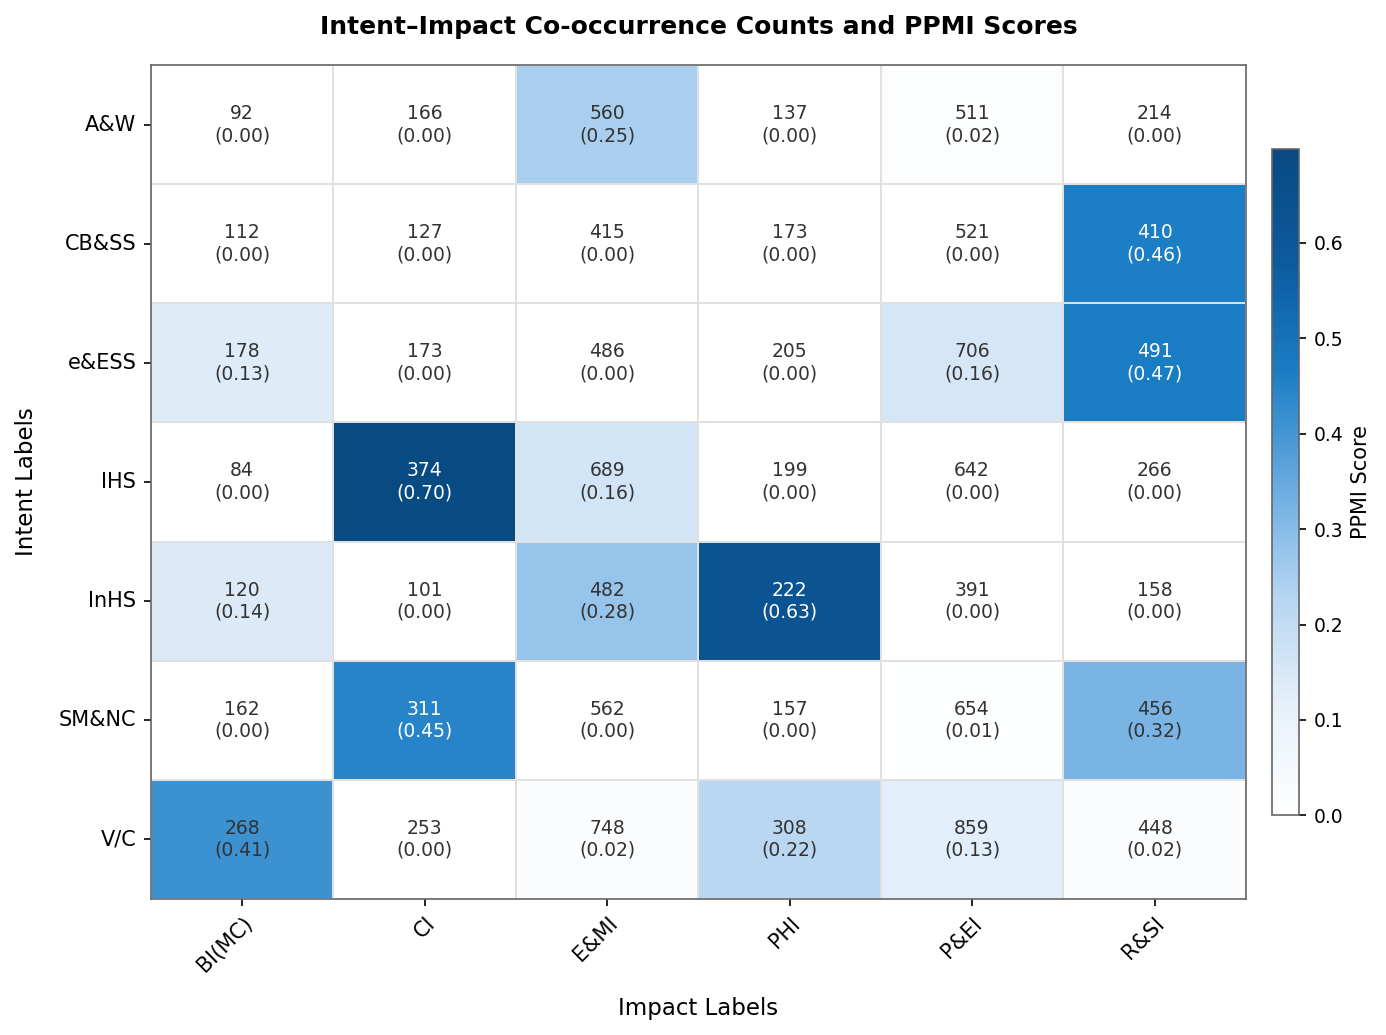


Saved minimal PDF to: ppmi_heatmap_minimal.pdf


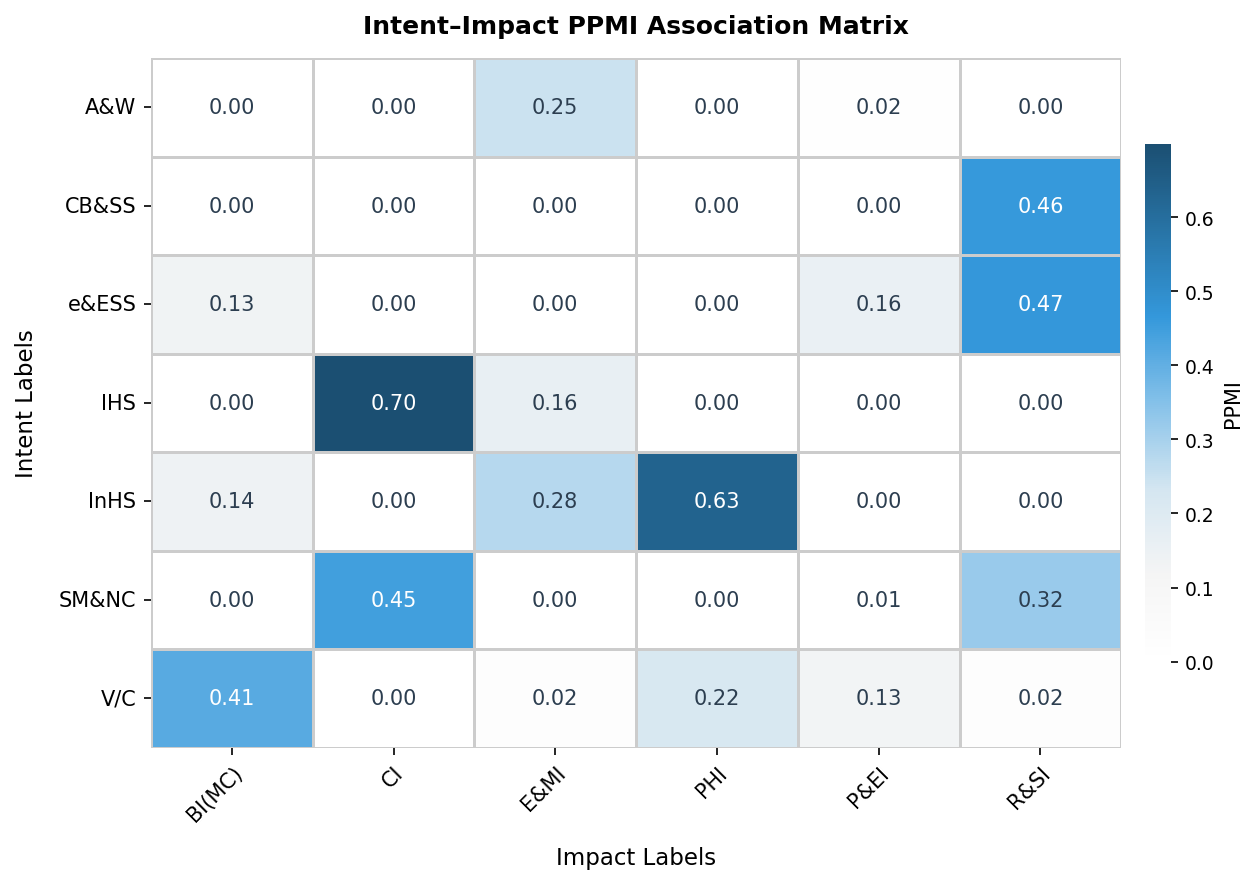


Saved diverging colormap PDF to: ppmi_heatmap_diverging.pdf


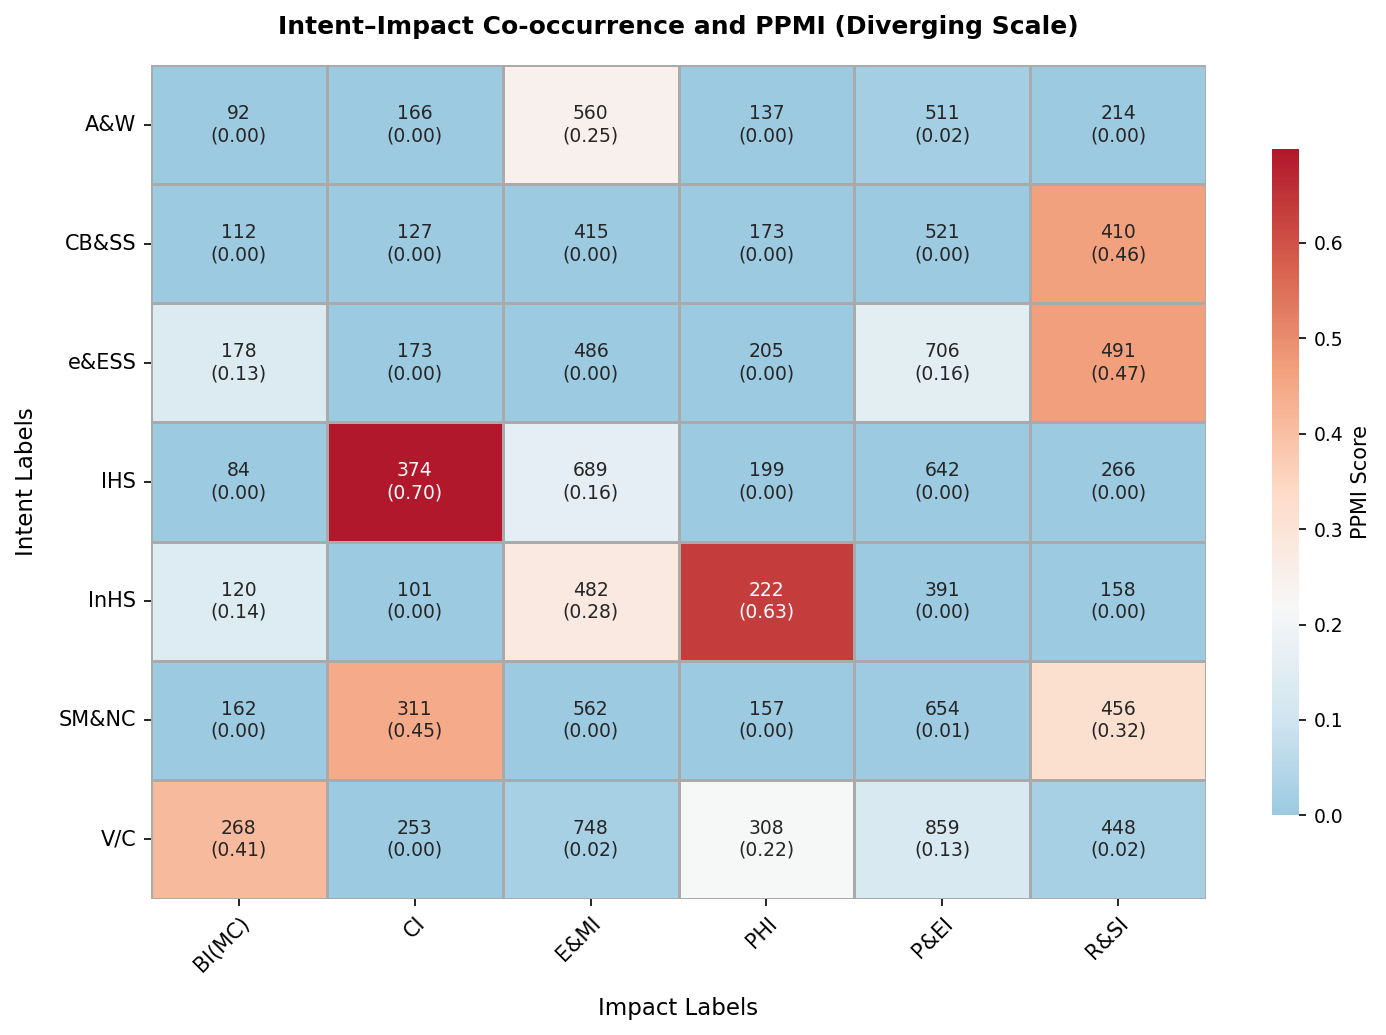


PPMI ANALYSIS SUMMARY

Dataset Size: 2408 posts

PPMI Score Statistics:
  Mean PPMI: 0.119
  Median PPMI: 0.000
  Max PPMI: 0.699
  Min PPMI: 0.000
  Std Dev: 0.189

Top 10 Strongest Associations (Highest PPMI):
  1. Informational Help-Seeking × Cognitive Impact
     PPMI: 0.699, Count: 374
  2. Instrumental Help-Seeking × Physical Health Impact
     PPMI: 0.634, Count: 222
  3. Emotional & Esteem Support-Seeking × Relational & Social Impact
     PPMI: 0.469, Count: 491
  4. Community Building & Solidarity Seeking × Relational & Social Impact
     PPMI: 0.463, Count: 410
  5. Sense-Making & Narrative Construction × Cognitive Impact
     PPMI: 0.445, Count: 311
  6. Venting / Catharsis × Behavioral Impact (Maladaptive Coping)
     PPMI: 0.413, Count: 268
  7. Sense-Making & Narrative Construction × Relational & Social Impact
     PPMI: 0.321, Count: 456
  8. Instrumental Help-Seeking × Economic & Material Impact
     PPMI: 0.276, Count: 482
  9. Advocacy & Warning × Economic & Material

In [4]:
# -*- coding: utf-8 -*-
"""
PPMI Analysis - Publication-Ready Visualization
Improved styling for research paper figures
"""

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from collections import defaultdict, Counter

# ============================================================================
# CONFIGURATION
# ============================================================================

# Set publication-quality defaults
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'axes.linewidth': 0.8,
    'axes.edgecolor': '#333333',
    'text.usetex': False,
})

# ============================================================================
# DATA LOADING
# ============================================================================

file_path = '/content/ACL_26-FinancialDiscussionsDataset.json'

with open(file_path, 'r') as f:
    data = json.load(f)

print(f"Loaded {len(data)} samples from the dataset")

# ============================================================================
# EXTRACT LABELS
# ============================================================================

all_intent_labels = set()
all_impact_labels = set()

for sample in data:
    all_intent_labels.update(sample['labels']['intent'])
    all_impact_labels.update(sample['labels']['impact'])

intent_labels = sorted(list(all_intent_labels))
impact_labels = sorted(list(all_impact_labels))

print(f"\nFound {len(intent_labels)} intent labels and {len(impact_labels)} impact labels")

# ============================================================================
# LABEL ABBREVIATIONS (for cleaner visualization)
# ============================================================================

# Intent label abbreviations
INTENT_ABBREV = {
    'Advocacy & Warning': 'A&W',
    'Community Building & Solidarity Seeking': 'CB&SS',
    'Emotional & Esteem Support-Seeking': 'e&ESS',
    'Informational Help-Seeking': 'IHS',
    'Instrumental Help-Seeking': 'InHS',
    'Sense-Making & Narrative Construction': 'SM&NC',
    'Venting / Catharsis': 'V/C',
}

# Impact label abbreviations
IMPACT_ABBREV = {
    'Behavioral Impact (Maladaptive Coping)': 'BI(MC)',
    'Cognitive Impact': 'CI',
    'Economic & Material Impact': 'E&MI',
    'Physical Health Impact': 'PHI',
    'Psychological & Emotional Impact': 'P&EI',
    'Relational & Social Impact': 'R&SI',
}

def get_short_label(label, label_type='intent'):
    """Get abbreviated label name."""
    if label_type == 'intent':
        return INTENT_ABBREV.get(label, label)
    else:
        return IMPACT_ABBREV.get(label, label)

# ============================================================================
# COUNT OCCURRENCES AND CO-OCCURRENCES
# ============================================================================

intent_counts = Counter()
impact_counts = Counter()
cooccurrence_counts = defaultdict(int)
N = len(data)

for sample in data:
    intents = sample['labels']['intent']
    impacts = sample['labels']['impact']

    for intent in intents:
        intent_counts[intent] += 1
    for impact in impacts:
        impact_counts[impact] += 1

    for intent in intents:
        for impact in impacts:
            cooccurrence_counts[(intent, impact)] += 1

# ============================================================================
# BUILD MATRICES
# ============================================================================

cooccurrence_matrix = pd.DataFrame(0, index=intent_labels, columns=impact_labels)
for (intent, impact), count in cooccurrence_counts.items():
    cooccurrence_matrix.loc[intent, impact] = count

ppmi_matrix = pd.DataFrame(0.0, index=intent_labels, columns=impact_labels)
for intent in intent_labels:
    for impact in impact_labels:
        count_ij = cooccurrence_matrix.loc[intent, impact]
        count_i = intent_counts[intent]
        count_j = impact_counts[impact]

        if count_ij == 0:
            ppmi_matrix.loc[intent, impact] = 0.0
        else:
            p_ij = count_ij / N
            p_i = count_i / N
            p_j = count_j / N
            pmi = np.log2(p_ij / (p_i * p_j))
            ppmi_matrix.loc[intent, impact] = max(0.0, pmi)

print("PPMI Matrix calculated!")

# ============================================================================
# PUBLICATION-READY VISUALIZATION
# ============================================================================

def create_publication_heatmap(ppmi_matrix, cooccurrence_matrix, output_path='ppmi_heatmap.pdf'):
    """
    Create a publication-quality heatmap for PPMI analysis.
    """

    # Create copies with abbreviated labels
    ppmi_display = ppmi_matrix.copy()
    ppmi_display.index = [get_short_label(l, 'intent') for l in ppmi_display.index]
    ppmi_display.columns = [get_short_label(l, 'impact') for l in ppmi_display.columns]

    cooc_display = cooccurrence_matrix.copy()
    cooc_display.index = [get_short_label(l, 'intent') for l in cooc_display.index]
    cooc_display.columns = [get_short_label(l, 'impact') for l in cooc_display.columns]

    # Custom colormap: White to deep blue (professional, colorblind-friendly)
    colors_blue = ['#FFFFFF', '#E6F0FA', '#B3D4F0', '#66A9E0', '#1A7DC4', '#0D5A9E', '#084A82']
    cmap_blue = LinearSegmentedColormap.from_list('ppmi_blue', colors_blue, N=256)

    # Alternative: White to teal (also professional)
    colors_teal = ['#FFFFFF', '#E0F4F4', '#A8DCDC', '#5CBCBC', '#2D9E9E', '#1A7A7A', '#0D5C5C']
    cmap_teal = LinearSegmentedColormap.from_list('ppmi_teal', colors_teal, N=256)

    # Alternative: Viridis-inspired (perceptually uniform)
    colors_viridis_light = ['#FFFFFF', '#E8F5E9', '#C8E6C9', '#81C784', '#4DB6AC', '#26A69A', '#00796B']
    cmap_viridis = LinearSegmentedColormap.from_list('ppmi_viridis', colors_viridis_light, N=256)

    # Select colormap (change this to use different palettes)
    selected_cmap = cmap_blue

    # Figure setup
    fig, ax = plt.subplots(figsize=(10, 7))

    # Create annotations with count and PPMI
    annotations = np.empty_like(ppmi_display.values, dtype=object)
    for i, intent in enumerate(ppmi_display.index):
        for j, impact in enumerate(ppmi_display.columns):
            count = int(cooc_display.loc[intent, impact])
            ppmi = ppmi_display.loc[intent, impact]
            annotations[i, j] = f"{count}\n({ppmi:.2f})"

    # Determine text colors based on background intensity
    ppmi_values = ppmi_display.values.astype(float)
    max_val = ppmi_values.max()
    threshold = max_val * 0.6

    # Create heatmap
    heatmap = sns.heatmap(
        ppmi_display.astype(float),
        annot=annotations,
        fmt='',
        cmap=selected_cmap,
        cbar_kws={
            'label': 'PPMI Score',
            'shrink': 0.8,
            'aspect': 25,
            'pad': 0.02
        },
        ax=ax,
        linewidths=0.8,
        linecolor='#E0E0E0',
        square=False,
        xticklabels=ppmi_display.columns,
        yticklabels=ppmi_display.index,
        vmin=0,
        vmax=None,
        annot_kws={'fontsize': 9, 'fontweight': 'normal'}
    )

    # Adjust annotation text colors for readability
    for i, text in enumerate(ax.texts):
        row = i // len(ppmi_display.columns)
        col = i % len(ppmi_display.columns)
        value = ppmi_values[row, col]
        if value > threshold:
            text.set_color('white')
        else:
            text.set_color('#333333')

    # Style colorbar
    cbar = heatmap.collections[0].colorbar
    cbar.ax.tick_params(labelsize=9)
    cbar.set_label('PPMI Score', fontsize=10, fontweight='medium')
    cbar.outline.set_edgecolor('#666666')
    cbar.outline.set_linewidth(0.8)

    # Labels and title
    ax.set_xlabel('Impact Labels', fontsize=11, fontweight='medium', labelpad=10)
    ax.set_ylabel('Intent Labels', fontsize=11, fontweight='medium', labelpad=10)
    ax.set_title('Intent–Impact Co-occurrence Counts and PPMI Scores',
                 fontsize=12, fontweight='semibold', pad=15)

    # Style tick labels (no rotation needed with short names)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor', fontsize=10, fontweight='medium')
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=10, fontweight='medium')

    # Add subtle border
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#666666')
        spine.set_linewidth(0.8)

    # Tight layout
    plt.tight_layout()

    # Save as high-quality PDF (600 DPI)
    fig.savefig(output_path, format='pdf', dpi=600, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    print(f"\nSaved high-quality PDF to: {output_path}")

    # Also save as PNG for preview
    png_path = output_path.replace('.pdf', '.png')
    fig.savefig(png_path, format='png', dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    print(f"Saved PNG preview to: {png_path}")

    plt.show()

    return fig, ax


def create_minimal_heatmap(ppmi_matrix, cooccurrence_matrix, output_path='ppmi_heatmap_minimal.pdf'):
    """
    Create a minimal, clean heatmap showing only PPMI values (no counts).
    Better for papers with space constraints.
    """

    # Create copy with abbreviated labels
    ppmi_display = ppmi_matrix.copy()
    ppmi_display.index = [get_short_label(l, 'intent') for l in ppmi_display.index]
    ppmi_display.columns = [get_short_label(l, 'impact') for l in ppmi_display.columns]

    # Professional grayscale-compatible colormap
    colors = ['#FFFFFF', '#F5F5F5', '#D4E6F1', '#85C1E9', '#3498DB', '#2874A6', '#1B4F72']
    cmap = LinearSegmentedColormap.from_list('ppmi_professional', colors, N=256)

    fig, ax = plt.subplots(figsize=(9, 6))

    ppmi_values = ppmi_display.values.astype(float)
    max_val = ppmi_values.max()
    threshold = max_val * 0.55

    # Heatmap with PPMI values only
    heatmap = sns.heatmap(
        ppmi_display.astype(float),
        annot=True,
        fmt='.2f',
        cmap=cmap,
        cbar_kws={
            'label': 'PPMI',
            'shrink': 0.75,
            'aspect': 20,
            'pad': 0.02
        },
        ax=ax,
        linewidths=0.5,
        linecolor='#CCCCCC',
        square=False,
        xticklabels=ppmi_display.columns,
        yticklabels=ppmi_display.index,
        vmin=0,
        annot_kws={'fontsize': 10, 'fontweight': 'medium'}
    )

    # Text color adjustment
    for i, text in enumerate(ax.texts):
        row = i // len(ppmi_display.columns)
        col = i % len(ppmi_display.columns)
        value = ppmi_values[row, col]
        text.set_color('white' if value > threshold else '#2C3E50')

    # Colorbar styling
    cbar = heatmap.collections[0].colorbar
    cbar.ax.tick_params(labelsize=9)
    cbar.set_label('PPMI', fontsize=10, fontweight='medium')

    # Labels
    ax.set_xlabel('Impact Labels', fontsize=11, fontweight='medium', labelpad=10)
    ax.set_ylabel('Intent Labels', fontsize=11, fontweight='medium', labelpad=10)
    ax.set_title('Intent–Impact PPMI Association Matrix',
                 fontsize=12, fontweight='semibold', pad=12)

    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor', fontsize=10, fontweight='medium')
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=10, fontweight='medium')

    plt.tight_layout()

    fig.savefig(output_path, format='pdf', dpi=600, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    print(f"\nSaved minimal PDF to: {output_path}")

    plt.show()

    return fig, ax


def create_diverging_heatmap(ppmi_matrix, cooccurrence_matrix, output_path='ppmi_heatmap_diverging.pdf'):
    """
    Create heatmap with diverging colormap centered at median PPMI.
    Highlights both strong and weak associations.
    """

    # Create copies with abbreviated labels
    ppmi_display = ppmi_matrix.copy()
    ppmi_display.index = [get_short_label(l, 'intent') for l in ppmi_display.index]
    ppmi_display.columns = [get_short_label(l, 'impact') for l in ppmi_display.columns]

    cooc_display = cooccurrence_matrix.copy()
    cooc_display.index = [get_short_label(l, 'intent') for l in cooc_display.index]
    cooc_display.columns = [get_short_label(l, 'impact') for l in cooc_display.columns]

    # Professional diverging colormap (cool to warm)
    colors_div = ['#2166AC', '#4393C3', '#92C5DE', '#D1E5F0', '#F7F7F7',
                  '#FDDBC7', '#F4A582', '#D6604D', '#B2182B']
    cmap_div = LinearSegmentedColormap.from_list('ppmi_diverging', colors_div, N=256)

    fig, ax = plt.subplots(figsize=(10, 7))

    ppmi_values = ppmi_display.values.astype(float)
    median_val = np.median(ppmi_values[ppmi_values > 0]) if np.any(ppmi_values > 0) else 0

    # Annotations
    annotations = np.empty_like(ppmi_display.values, dtype=object)
    for i, intent in enumerate(ppmi_display.index):
        for j, impact in enumerate(ppmi_display.columns):
            count = int(cooc_display.loc[intent, impact])
            ppmi = ppmi_display.loc[intent, impact]
            annotations[i, j] = f"{count}\n({ppmi:.2f})"

    heatmap = sns.heatmap(
        ppmi_display.astype(float),
        annot=annotations,
        fmt='',
        cmap=cmap_div,
        center=median_val,
        cbar_kws={
            'label': 'PPMI Score',
            'shrink': 0.8,
            'aspect': 25
        },
        ax=ax,
        linewidths=0.6,
        linecolor='#AAAAAA',
        xticklabels=ppmi_display.columns,
        yticklabels=ppmi_display.index,
        annot_kws={'fontsize': 9}
    )

    # Colorbar styling
    cbar = heatmap.collections[0].colorbar
    cbar.ax.tick_params(labelsize=9)
    cbar.set_label('PPMI Score', fontsize=10, fontweight='medium')

    ax.set_xlabel('Impact Labels', fontsize=11, fontweight='medium', labelpad=10)
    ax.set_ylabel('Intent Labels', fontsize=11, fontweight='medium', labelpad=10)
    ax.set_title('Intent–Impact Co-occurrence and PPMI (Diverging Scale)',
                 fontsize=12, fontweight='semibold', pad=15)

    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor', fontsize=10, fontweight='medium')
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=10, fontweight='medium')

    plt.tight_layout()

    fig.savefig(output_path, format='pdf', dpi=600, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    print(f"\nSaved diverging colormap PDF to: {output_path}")

    plt.show()

    return fig, ax


# ============================================================================
# GENERATE VISUALIZATIONS
# ============================================================================

# Option 1: Full heatmap with counts and PPMI (blue sequential)
print("\n" + "="*60)
print("Generating Publication-Ready Visualizations")
print("="*60)

fig1, ax1 = create_publication_heatmap(
    ppmi_matrix,
    cooccurrence_matrix,
    output_path='ppmi_heatmap_full.pdf'
)

# Option 2: Minimal heatmap with PPMI only
fig2, ax2 = create_minimal_heatmap(
    ppmi_matrix,
    cooccurrence_matrix,
    output_path='ppmi_heatmap_minimal.pdf'
)

# Option 3: Diverging colormap version
fig3, ax3 = create_diverging_heatmap(
    ppmi_matrix,
    cooccurrence_matrix,
    output_path='ppmi_heatmap_diverging.pdf'
)

# ============================================================================
# SUMMARY STATISTICS
# ============================================================================

print("\n" + "="*60)
print("PPMI ANALYSIS SUMMARY")
print("="*60)

print(f"\nDataset Size: {N} posts")

print(f"\nPPMI Score Statistics:")
ppmi_values = ppmi_matrix.values.flatten()
print(f"  Mean PPMI: {ppmi_values.mean():.3f}")
print(f"  Median PPMI: {np.median(ppmi_values):.3f}")
print(f"  Max PPMI: {ppmi_values.max():.3f}")
print(f"  Min PPMI: {ppmi_values.min():.3f}")
print(f"  Std Dev: {ppmi_values.std():.3f}")

print(f"\nTop 10 Strongest Associations (Highest PPMI):")
ppmi_flat = []
for intent in intent_labels:
    for impact in impact_labels:
        ppmi_flat.append((intent, impact, ppmi_matrix.loc[intent, impact]))

ppmi_flat.sort(key=lambda x: x[2], reverse=True)
for i, (intent, impact, ppmi) in enumerate(ppmi_flat[:10], 1):
    count = int(cooccurrence_matrix.loc[intent, impact])
    print(f"  {i}. {intent} × {impact}")
    print(f"     PPMI: {ppmi:.3f}, Count: {count}")

print(f"\nWeakest Associations (PPMI = 0):")
zero_ppmi = [(intent, impact) for intent, impact, ppmi in ppmi_flat if ppmi == 0]
print(f"  Found {len(zero_ppmi)} pairs with PPMI = 0")

print("\n" + "="*60)
print("PDF files saved at 600 DPI - ready for publication!")
print("="*60)